# Multi-Asset Equity Analytics with SQL (DuckDB)

**What this project does:** builds a small analytics engine over daily equity prices and answers how has each name performed, how risky is it, when did the trend flip, how deep were the drawdowns, which names are best on a risk-adjusted basis, and how correlated is everything.

**SQL techniques demonstrated:**
1. `LAG` window function for daily returns
2. Windowed moving averages with explicit frames (`ROWS BETWEEN ...`) and a trend regime signal
3. Cumulative compounding via log returns (`EXP(SUM(LN(...)))`)
4. Rolling annualized volatility (`STDDEV_SAMP` over a window)
5. Running peak and drawdown (`MAX ... UNBOUNDED PRECEDING`)
6. Risk-adjusted leaderboard with `RANK()`
7. Sector aggregation with `GROUP BY`
8. Pairwise correlation via self-join and the `CORR` aggregate


## 0. Setup

In [1]:
!pip install duckdb yfinance --quiet

In [2]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# universe with hardcoded sector map
UNIVERSE = {
    "AAPL": "Technology", "MSFT": "Technology", "NVDA": "Technology",
    "JPM": "Financials", "GS": "Financials", "BAC": "Financials",
    "XOM": "Energy", "CVX": "Energy",
    "KO": "Consumer Staples", "PG": "Consumer Staples",
    "JNJ": "Health Care", "PFE": "Health Care",
}
TICKERS = list(UNIVERSE.keys())

### Load data

Tries real Yahoo Finance data first. If that fails (offline, rate limit, API change), it generates a simulated panel using a market + sector + idiosyncratic factor model. Either path produces the same schema: `ticker, sector, date, close`.

In [3]:
def load_real(start="2023-01-01"):
    import yfinance as yf
    raw = yf.download(TICKERS, start=start, auto_adjust=True, progress=False)["Close"]
    long = raw.reset_index().melt(id_vars="Date", var_name="ticker", value_name="close")
    long = long.dropna(subset=["close"])
    long["sector"] = long["ticker"].map(UNIVERSE)
    long = long.rename(columns={"Date": "date"})
    long["date"] = pd.to_datetime(long["date"]).dt.date
    if long["ticker"].nunique() < len(TICKERS):
        raise ValueError("incomplete download")
    return long[["ticker", "sector", "date", "close"]]

def load_simulated(seed=42, n_days=756):
    rng = np.random.default_rng(seed)
    sectors = sorted(set(UNIVERSE.values()))
    dates = pd.bdate_range("2023-01-02", periods=n_days)
    mkt = rng.normal(0.0004, 0.010, n_days) # market factor
    sec_f = {s: rng.normal(0, 0.006, n_days) for s in sectors} # sector factors
    params = { # ticker: (annual drift, idio daily vol, market beta, sector beta)
        "AAPL": (0.18, 0.011, 1.1, 0.8), "MSFT": (0.16, 0.010, 1.0, 0.8), "NVDA": (0.35, 0.020, 1.4, 0.9),
        "JPM": (0.10, 0.010, 1.1, 0.9), "GS": (0.09, 0.012, 1.2, 0.9), "BAC": (0.08, 0.013, 1.2, 0.9),
        "XOM": (0.07, 0.012, 0.8, 1.0), "CVX": (0.06, 0.011, 0.8, 1.0),
        "KO": (0.05, 0.007, 0.5, 0.7), "PG": (0.05, 0.007, 0.5, 0.7),
        "JNJ": (0.06, 0.008, 0.6, 0.7), "PFE": (0.03, 0.011, 0.6, 0.7),
    }
    rows = []
    for tk, sec in UNIVERSE.items():
        drift, idio, mb, sb = params[tk]
        r = drift / 252 + mb * mkt + sb * sec_f[sec] + rng.normal(0, idio, n_days)
        price = 100 * np.exp(np.cumsum(r))
        for d, p in zip(dates, price):
            rows.append((tk, sec, d.date(), round(float(p), 4)))
    return pd.DataFrame(rows, columns=["ticker", "sector", "date", "close"])

try:
    df = load_real()
    SOURCE = "Yahoo Finance (real market data)"
except Exception as e:
    print("Falling back to simulated data:", e)
    df = load_simulated()
    SOURCE = "Simulated (reproducible factor model)"

print("Data source:", SOURCE)
print("Rows:", len(df), "| Tickers:", df["ticker"].nunique(),
      "| Date range:", df["date"].min(), "to", df["date"].max())
df.head()

ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['MSFT']: OperationalError('database is locked')


Falling back to simulated data: incomplete download
Data source: Simulated (reproducible factor model)
Rows: 9072 | Tickers: 12 | Date range: 2023-01-02 to 2025-11-24


,ticker,sector,date,close
0,AAPL,Technology,2023-01-02,99.6254
1,AAPL,Technology,2023-01-03,98.0569
2,AAPL,Technology,2023-01-04,97.3436
3,AAPL,Technology,2023-01-05,99.8662
4,AAPL,Technology,2023-01-06,99.8751


### Load into DuckDB

In [4]:
con = duckdb.connect()
con.register("prices_raw", df)
con.execute("""
    CREATE OR REPLACE TABLE prices AS
    SELECT ticker, sector, CAST(date AS DATE) AS date, close
    FROM prices_raw
    ORDER BY ticker, date
""")
con.execute("SELECT ticker, COUNT(*) AS n_days, MIN(date) AS start, MAX(date) AS end "
            "FROM prices GROUP BY ticker ORDER BY ticker").df()

,ticker,n_days,start,end
0,AAPL,756,2023-01-02,2025-11-24
1,BAC,756,2023-01-02,2025-11-24
2,CVX,756,2023-01-02,2025-11-24
3,GS,756,2023-01-02,2025-11-24
4,JNJ,756,2023-01-02,2025-11-24
5,JPM,756,2023-01-02,2025-11-24
6,KO,756,2023-01-02,2025-11-24
7,MSFT,756,2023-01-02,2025-11-24
8,NVDA,756,2023-01-02,2025-11-24
9,PFE,756,2023-01-02,2025-11-24


## 1. Daily returns (`LAG`)

In [5]:
con.execute("""
CREATE OR REPLACE TABLE returns AS
WITH r AS (
  SELECT
    ticker, sector, date, close,
    close / LAG(close) OVER (PARTITION BY ticker ORDER BY date) - 1 AS daily_return
  FROM prices
)
SELECT ticker, sector, date, close, COALESCE(daily_return, 0) AS daily_return
FROM r
""")
con.execute("SELECT ticker, date, ROUND(close,2) AS close, ROUND(daily_return,4) AS daily_return "
            "FROM returns WHERE ticker = 'AAPL' ORDER BY date LIMIT 5").df()

,ticker,date,close,daily_return
0,AAPL,2023-01-02,99.63,0.0000
1,AAPL,2023-01-03,98.06,-0.0157
2,AAPL,2023-01-04,97.34,-0.0073
3,AAPL,2023-01-05,99.87,0.0259
4,AAPL,2023-01-06,99.88,0.0001


## 2. Moving averages and a trend regime signal (windowed frames)

In [6]:
con.execute("""
WITH ma AS (
  SELECT
    ticker, date, close,
    AVG(close) OVER (PARTITION BY ticker ORDER BY date
                     ROWS BETWEEN 19 PRECEDING AND CURRENT ROW) AS sma20,
    AVG(close) OVER (PARTITION BY ticker ORDER BY date
                     ROWS BETWEEN 49 PRECEDING AND CURRENT ROW) AS sma50
  FROM prices
)
SELECT
  ticker, date,
  ROUND(close,2) AS px, ROUND(sma20,2) AS sma20, ROUND(sma50,2) AS sma50,
  CASE WHEN sma20 > sma50 THEN 'bullish' ELSE 'bearish' END AS regime
FROM ma
WHERE ticker = 'NVDA'
ORDER BY date DESC
LIMIT 8
""").df()

,ticker,date,px,sma20,sma50,regime
0,NVDA,2025-11-24,398.63,362.00,364.80,bearish
1,NVDA,2025-11-21,386.06,361.59,363.79,bearish
2,NVDA,2025-11-20,376.74,361.05,363.04,bearish
3,NVDA,2025-11-19,360.68,361.29,362.48,bearish
4,NVDA,2025-11-18,365.08,362.43,362.24,bullish
5,NVDA,2025-11-17,354.39,362.61,361.89,bullish
6,NVDA,2025-11-14,363.10,362.73,361.81,bullish
7,NVDA,2025-11-13,361.34,362.73,361.44,bullish


## 3. Cumulative return, growth of \$1 (log-return compounding)

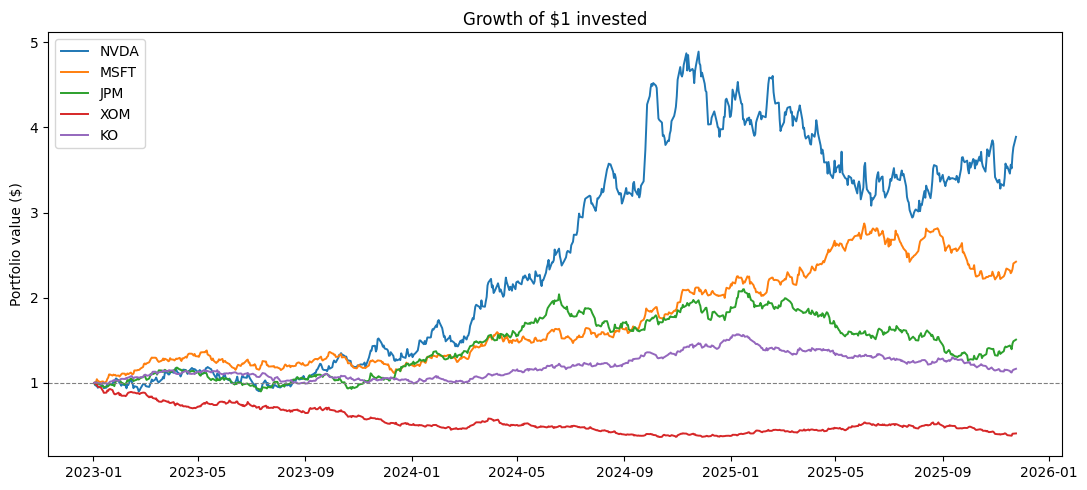

In [7]:
growth = con.execute("""
SELECT
  ticker, date,
  EXP(SUM(LN(1 + daily_return)) OVER (PARTITION BY ticker ORDER BY date)) AS growth_of_1
FROM returns
""").df()

pivot = growth.pivot(index="date", columns="ticker", values="growth_of_1")
plt.figure(figsize=(11, 5))
for t in ["NVDA", "MSFT", "JPM", "XOM", "KO"]:
    if t in pivot.columns:
        plt.plot(pivot.index, pivot[t], label=t, linewidth=1.4)
plt.axhline(1.0, color="gray", linewidth=0.8, linestyle="--")
plt.title("Growth of $1 invested")
plt.ylabel("Portfolio value ($)")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Rolling annualized volatility (windowed `STDDEV_SAMP`)

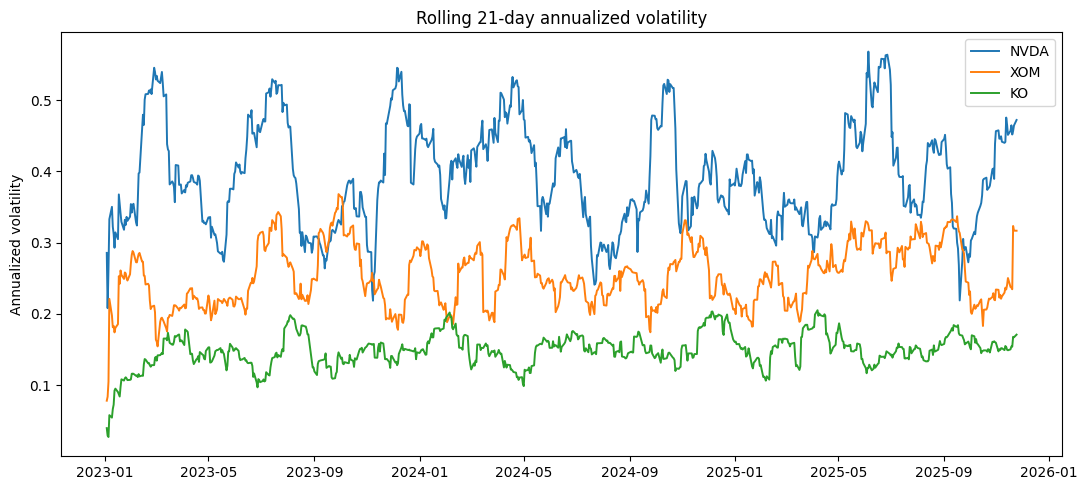

In [8]:
vol = con.execute("""
SELECT
  ticker, date,
  STDDEV_SAMP(daily_return) OVER (PARTITION BY ticker ORDER BY date
      ROWS BETWEEN 20 PRECEDING AND CURRENT ROW) * SQRT(252) AS vol_21d
FROM returns
""").df()

vpiv = vol.pivot(index="date", columns="ticker", values="vol_21d")
plt.figure(figsize=(11, 5))
for t in ["NVDA", "XOM", "KO"]:
    if t in vpiv.columns:
        plt.plot(vpiv.index, vpiv[t], label=t, linewidth=1.4)
plt.title("Rolling 21-day annualized volatility")
plt.ylabel("Annualized volatility")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Drawdown and max drawdown (running peak)

ticker  max_drawdown
   XOM       -0.6348
   CVX       -0.5075
   JPM       -0.4004
  NVDA       -0.3984
    GS       -0.3532
  AAPL       -0.3308
   BAC       -0.3088
   PFE       -0.2920
    KO       -0.2855
    PG       -0.2398
  MSFT       -0.2289
   JNJ       -0.2105


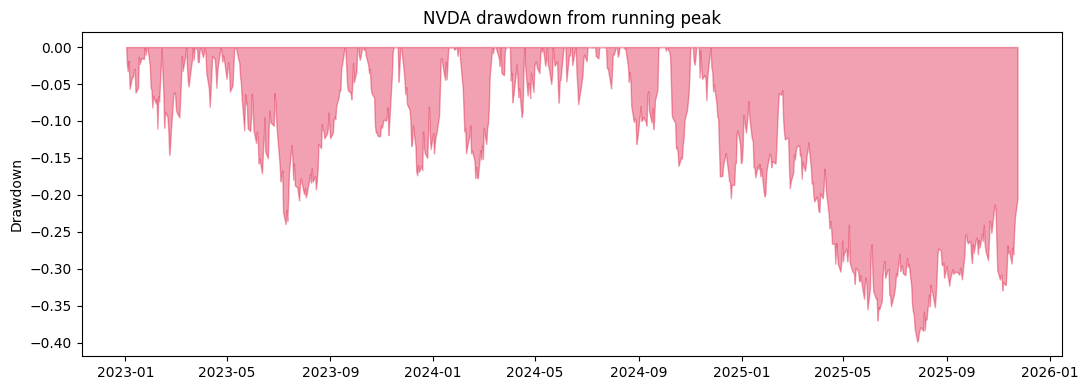

In [9]:
con.execute("""
CREATE OR REPLACE TABLE drawdowns AS
WITH dd AS (
  SELECT
    ticker, date, close,
    MAX(close) OVER (PARTITION BY ticker ORDER BY date
        ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS running_peak
  FROM prices
)
SELECT ticker, date, close, close / running_peak - 1 AS drawdown
FROM dd
""")

# max drawdown per ticker
mdd = con.execute("""
SELECT ticker, ROUND(MIN(drawdown), 4) AS max_drawdown
FROM drawdowns GROUP BY ticker ORDER BY max_drawdown
""").df()
print(mdd.to_string(index=False))

# plot drawdown path for one name
dpiv = con.execute("SELECT date, drawdown FROM drawdowns WHERE ticker='NVDA' ORDER BY date").df()
plt.figure(figsize=(11, 4))
plt.fill_between(dpiv["date"], dpiv["drawdown"], 0, color="crimson", alpha=0.4)
plt.title("NVDA drawdown from running peak")
plt.ylabel("Drawdown")
plt.tight_layout()
plt.show()

## 6. Risk-adjusted leaderboard (`RANK`)

In [10]:
con.execute("""
WITH stats AS (
  SELECT
    ticker,
    AVG(daily_return) * 252 AS ann_return,
    STDDEV_SAMP(daily_return) * SQRT(252) AS ann_vol,
    AVG(daily_return) / NULLIF(STDDEV_SAMP(daily_return), 0) * SQRT(252) AS sharpe
  FROM returns
  GROUP BY ticker
)
SELECT
  RANK() OVER (ORDER BY sharpe DESC) AS rank,
  ticker,
  ROUND(ann_return, 3) AS ann_return,
  ROUND(ann_vol, 3) AS ann_vol,
  ROUND(sharpe, 2) AS sharpe
FROM stats
ORDER BY sharpe DESC
""").df()

,rank,ticker,ann_return,ann_vol,sharpe
0,1,MSFT,0.323,0.237,1.37
1,2,NVDA,0.533,0.402,1.33
2,3,BAC,0.269,0.293,0.92
3,4,JPM,0.170,0.257,0.66
4,5,JNJ,0.072,0.167,0.43
5,6,KO,0.063,0.152,0.41
6,7,GS,0.105,0.275,0.38
7,8,AAPL,0.050,0.266,0.19
8,9,PG,0.017,0.155,0.11
9,10,PFE,0.021,0.211,0.10


## 7. Sector performance (`GROUP BY` aggregation)

In [11]:
con.execute("""
SELECT
  sector,
  COUNT(DISTINCT ticker) AS n_names,
  ROUND(AVG(daily_return) * 252, 3) AS avg_ann_return,
  ROUND(STDDEV_SAMP(daily_return) * SQRT(252), 3) AS avg_ann_vol
FROM returns
GROUP BY sector
ORDER BY avg_ann_return DESC
""").df()

,sector,n_names,avg_ann_return,avg_ann_vol
0,Technology,3,0.302,0.310
1,Financials,3,0.182,0.275
2,Health Care,2,0.046,0.190
3,Consumer Staples,2,0.040,0.153
4,Energy,2,-0.225,0.243


## 8. Correlation matrix (self-join + `CORR`)

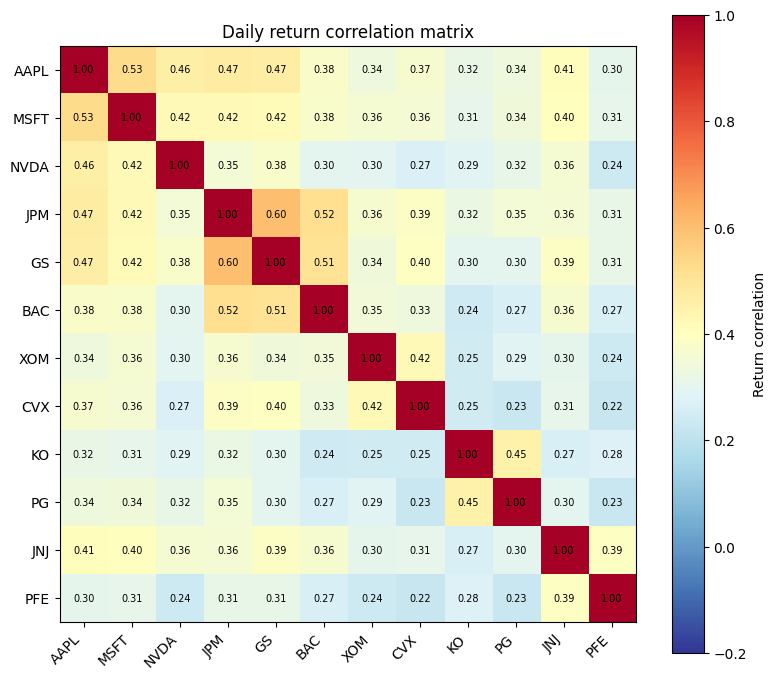

In [12]:
corr_long = con.execute("""
SELECT a.ticker AS t1, b.ticker AS t2, CORR(a.daily_return, b.daily_return) AS corr
FROM returns a
JOIN returns b ON a.date = b.date
GROUP BY a.ticker, b.ticker
""").df()

cmat = corr_long.pivot(index="t1", columns="t2", values="corr").reindex(index=TICKERS, columns=TICKERS)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cmat.values, cmap="RdYlBu_r", vmin=-0.2, vmax=1.0)
ax.set_xticks(range(len(TICKERS))); ax.set_xticklabels(TICKERS, rotation=45, ha="right")
ax.set_yticks(range(len(TICKERS))); ax.set_yticklabels(TICKERS)
for i in range(len(TICKERS)):
    for j in range(len(TICKERS)):
        ax.text(j, i, f"{cmat.values[i, j]:.2f}", ha="center", va="center", fontsize=7)
plt.colorbar(im, label="Return correlation")
plt.title("Daily return correlation matrix")
plt.tight_layout()
plt.show()

## What this demonstrates

Every metric above (returns, moving-average signals, compounding, rolling volatility, drawdown, risk-adjusted ranking, sector rollups, and correlation) was computed in SQL. Together they cover the window-function, CTE, aggregation, ranking, join, and statistical-aggregate patterns, applied to genuinely financial questions rather than random toy queries.